# Notebook 7: Primal-Dual Interior Point Method

In the previous notebook we saw the pure barrier method: for each $\mu$, we run an entire Newton optimization. This is wasteful — we don't need to solve each subproblem to high accuracy before reducing $\mu$.

The **primal-dual IPM** is smarter: it simultaneously optimizes $(x, z_l, z_u, y)$ together, treating the perturbed KKT system as a system of equations to solve with one Newton step per iteration.

**Prerequisites:** Notebooks 1-6

**Learning objectives:**
- Derive the Newton step for the perturbed KKT system
- Implement the fraction-to-boundary rule for step sizes
- Extend to equality constraints
- Test on HS071 benchmark problem

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve, lu_factor, lu_solve
import warnings
warnings.filterwarnings('ignore')

np.set_printoptions(precision=8, suppress=True)
print('Libraries loaded.')

Libraries loaded.


## 1. Limitation of Pure Barrier Method

In the barrier method, for each $\mu$ we need to fully solve:
$$\min_x \phi(x, \mu) = f(x) - \mu \sum_i \log(x_i - x_{l,i}) - \mu \sum_i \log(x_{u,i} - x_i)$$

This requires many Newton iterations at each $\mu$ level. If we need to decrease $\mu$ from $1.0$ to $10^{-8}$, that is roughly 18 doublings, and each level might require 10–20 Newton steps: **180–360 total Newton steps just for the outer structure.**

**Primal-dual idea:** Don't bother fully solving each subproblem. Instead, write down the first-order optimality conditions (perturbed KKT) as a *system of equations* and apply Newton's method to the *whole system at once*.

The variables are: $(x, z_l, z_u, y)$ — primal variables, bound multipliers, and equality multipliers.

## 2. Primal-Dual System (Bounds Only)

Consider the problem with bounds only:
$$\min f(x), \quad x_l \leq x \leq x_u$$

The perturbed KKT conditions are:
$$F(x, z_l, z_u; \mu) = \begin{pmatrix} \nabla f(x) - z_l + z_u \\ Z_l (x - x_l) - \mu e \\ Z_u (x_u - x) - \mu e \end{pmatrix} = 0$$

where $Z_l = \text{diag}(z_l)$, $Z_u = \text{diag}(z_u)$, $e = (1, \ldots, 1)^T$.

Apply Newton's method: $J \cdot \Delta w = -F$ where $w = (x, z_l, z_u)$:
$$\begin{pmatrix} \nabla^2 f & -I & I \\ Z_l & S_l & 0 \\ -Z_u & 0 & S_u \end{pmatrix} \begin{pmatrix} dx \\ dz_l \\ dz_u \end{pmatrix} = -\begin{pmatrix} r_d \\ r_{cl} \\ r_{cu} \end{pmatrix}$$

where $S_l = \text{diag}(x - x_l)$, $S_u = \text{diag}(x_u - x)$, and:
- $r_d = \nabla f(x) - z_l + z_u$ (dual residual / stationarity)
- $r_{cl} = Z_l s_l - \mu e$ (lower complementarity)
- $r_{cu} = Z_u s_u - \mu e$ (upper complementarity)

**Eliminating $dz_l$ and $dz_u$:** From rows 2 and 3:
$$dz_l = S_l^{-1}(-r_{cl} - Z_l dx) = S_l^{-1}(-r_{cl}) - (Z_l/S_l) dx$$
$$dz_u = S_u^{-1}(-r_{cu} + Z_u dx) = S_u^{-1}(-r_{cu}) + (Z_u/S_u) dx$$

Substitute into row 1:
$$(\nabla^2 f + \underbrace{Z_l/S_l + Z_u/S_u}_{\Sigma}) dx = -r_d + S_l^{-1} r_{cl} + S_u^{-1} r_{cu}$$

This is a single $n \times n$ system for $dx$. Then recover $dz_l$, $dz_u$.

In [2]:
def fraction_to_boundary(var, dvar, bound, direction='lower', tau=0.99):
    """
    Compute max step size alpha such that var + alpha*dvar >= (1-tau)*bound.

    For lower bounds: var + alpha*dvar >= tau * (var - x_l) + x_l
    Equivalently: slack + alpha*dslack >= (1-tau)*slack
    => alpha <= -tau * slack_i / dslack_i  for dslack_i < 0

    This keeps the slack at least tau * current_slack > 0, staying strictly feasible.

    Parameters
    ----------
    var : array, current slack (x - x_l) or (x_u - x)
    dvar : array, step direction for slack
    bound : not used explicitly (just for documentation)
    tau : float, fraction-to-boundary parameter (default 0.99 like Ipopt)

    Returns
    -------
    alpha_max : float in (0, 1]
    """
    alpha = 1.0
    for i in range(len(var)):
        if dvar[i] < 0:
            # var[i] + alpha*dvar[i] >= (1-tau)*var[i]
            # alpha <= tau * var[i] / (-dvar[i])
            alpha_i = tau * var[i] / (-dvar[i])
            alpha = min(alpha, alpha_i)
    return max(alpha, 1e-20)  # never exactly zero


# Quick test
s = np.array([1.0, 0.5, 2.0])
ds = np.array([-0.9, -0.1, 0.5])
alpha_max = fraction_to_boundary(s, ds, None)
print(f'FTB test: s = {s}, ds = {ds}')
print(f'alpha_max = {alpha_max:.6f}')
s_new = s + alpha_max * ds
print(f's_new = {s_new}  (all > 0? {all(s_new > 0)})')
print(f'Minimum fraction kept: {min(s_new / s):.4f}  (should be >= 1-tau = 0.01)')

FTB test: s = [1.  0.5 2. ], ds = [-0.9 -0.1  0.5]
alpha_max = 1.000000
s_new = [0.1 0.4 2.5]  (all > 0? True)
Minimum fraction kept: 0.1000  (should be >= 1-tau = 0.01)


In [3]:
def assemble_and_solve_kkt(H_plus_Sigma, J, r_d, r_p):
    """
    Assemble and solve the augmented KKT system:

      [H+Sigma   J^T] [dx]   [-r_d]
      [J         0  ] [dy] = [-r_p]

    Parameters
    ----------
    H_plus_Sigma : array, shape (n, n), H + Sigma (symmetric, ideally positive definite)
    J : array, shape (m, n), constraint Jacobian
    r_d : array, shape (n,), dual residual
    r_p : array, shape (m,), primal residual (constraint violation)

    Returns
    -------
    dx : array, shape (n,)
    dy : array, shape (m,)
    """
    n = H_plus_Sigma.shape[0]
    m = J.shape[0] if J.ndim == 2 else 0

    if m == 0:
        # No equality constraints: just solve H dx = -r_d
        dx = np.linalg.solve(H_plus_Sigma, -r_d)
        return dx, np.zeros(0)

    # Build full KKT matrix
    K = np.zeros((n + m, n + m))
    K[:n, :n] = H_plus_Sigma
    K[:n, n:] = J.T
    K[n:, :n] = J
    # (2,2) block is zero (no constraint regularization here)

    rhs = np.concatenate([-r_d, -r_p])

    try:
        sol = np.linalg.solve(K, rhs)
    except np.linalg.LinAlgError:
        # Add regularization if singular
        K[:n, :n] += 1e-6 * np.eye(n)
        K[n:, n:] -= 1e-8 * np.eye(m)
        sol = np.linalg.solve(K, rhs)

    return sol[:n], sol[n:]


print('assemble_and_solve_kkt defined.')

assemble_and_solve_kkt defined.


## 3. Primal-Dual IPM with Equality Constraints

Now add equality constraints $g(x) = 0$ (where $g : \mathbb{R}^n \to \mathbb{R}^m$).

The problem is:
$$\min f(x) \quad \text{s.t.} \quad g(x) = 0, \quad x_l \leq x \leq x_u$$

The perturbed KKT conditions are:
$$\nabla f(x) + J(x)^T y - z_l + z_u = 0 \quad (\text{stationarity})$$
$$g(x) = 0 \quad (\text{feasibility})$$
$$Z_l (x - x_l) = \mu e \quad (\text{lower complementarity})$$
$$Z_u (x_u - x) = \mu e \quad (\text{upper complementarity})$$

The Newton step on this system gives the **KKT (saddle-point) linear system**:

$$\begin{bmatrix} H + \Sigma & J^T \\ J & 0 \end{bmatrix} \begin{bmatrix} dx \\ dy \end{bmatrix} = -\begin{bmatrix} r_d \\ r_p \end{bmatrix}$$

where:
- $H = \nabla^2 \mathcal{L}(x, y) = \nabla^2 f(x) + \sum_j y_j \nabla^2 g_j(x)$ (Lagrangian Hessian)
- $\Sigma = Z_l / S_l + Z_u / S_u$ (barrier diagonal from bound constraints)
- $r_d = \nabla f(x) + J^T y - z_l + z_u$ (dual/stationarity residual)
- $r_p = g(x)$ (primal/feasibility residual)

The $\Sigma$ term is the same one we computed from the barrier Hessian in notebook 6!

In [4]:
def primal_dual_ipm(f, grad_f, hess_f_lag,
                    g_eq, jac_eq,
                    x0, x_l, x_u,
                    mu0=0.1, tol=1e-8, max_iter=200,
                    verbose=True):
    """
    Primal-dual interior point method for:
      min f(x)  s.t.  g_eq(x) = 0,  x_l <= x <= x_u

    Parameters
    ----------
    f : callable(x) -> float
    grad_f : callable(x) -> array (n,)
    hess_f_lag : callable(x, y) -> array (n,n), Hessian of Lagrangian
    g_eq : callable(x) -> array (m,)  [None if no equality constraints]
    jac_eq : callable(x) -> array (m, n)  [None if no equality constraints]
    x0 : array (n,), starting point (must be strictly interior: x_l < x0 < x_u)
    x_l, x_u : arrays (n,), bounds
    mu0 : float, initial barrier parameter
    tol : float, convergence tolerance
    max_iter : int
    verbose : bool

    Returns
    -------
    x : array (n,), solution
    y : array (m,), equality multipliers
    z_l : array (n,), lower bound multipliers
    z_u : array (n,), upper bound multipliers
    history : list of dicts with iteration info
    """
    n = len(x0)
    has_eq = g_eq is not None
    m = len(g_eq(x0)) if has_eq else 0

    # --- Initialization ---
    x = x0.copy()
    # Ensure strictly interior
    for i in range(n):
        if np.isfinite(x_l[i]):
            x[i] = max(x[i], x_l[i] + 1e-4)
        if np.isfinite(x_u[i]):
            x[i] = min(x[i], x_u[i] - 1e-4)

    s_l = x - x_l  # lower slacks
    s_u = x_u - x  # upper slacks

    mu = mu0
    z_l = mu / s_l  # initialize from barrier optimality
    z_u = mu / s_u
    y   = np.zeros(m)

    history = []

    if verbose:
        print(f'{'Iter':>5}  {'f(x)':>14}  {'||r_d||':>10}  {'||r_p||':>10}  {'compl':>10}  {'mu':>8}')
        print('-'*65)

    tau = 0.99  # fraction-to-boundary parameter

    for iteration in range(max_iter):
        # --- Compute residuals ---
        gf = grad_f(x)
        J  = jac_eq(x) if has_eq else np.zeros((0, n))
        r_d = gf + J.T @ y - z_l + z_u
        r_p = g_eq(x) if has_eq else np.zeros(0)
        r_cl = z_l * s_l - mu  # complementarity residuals
        r_cu = z_u * s_u - mu

        # Complementarity measure
        compl = (np.dot(z_l, s_l) + np.dot(z_u, s_u)) / (2 * n)

        norm_rd = np.linalg.norm(r_d)
        norm_rp = np.linalg.norm(r_p) if m > 0 else 0.0

        info = {
            'iter': iteration, 'f': f(x), 'x': x.copy(),
            'mu': mu, 'norm_rd': norm_rd, 'norm_rp': norm_rp,
            'compl': compl, 'z_l': z_l.copy(), 'z_u': z_u.copy(), 'y': y.copy()
        }
        history.append(info)

        if verbose:
            print(f'{iteration:5d}  {f(x):14.8f}  {norm_rd:10.3e}  {norm_rp:10.3e}  {compl:10.3e}  {mu:8.2e}')

        # --- Check convergence ---
        if norm_rd < tol and norm_rp < tol and compl < tol:
            if verbose:
                print(f'Converged at iteration {iteration}!')
            break

        # --- Assemble reduced system ---
        # H_L = Hessian of Lagrangian
        H_L = hess_f_lag(x, y)

        # Sigma = Z_l/S_l + Z_u/S_u (diagonal)
        Sigma_diag = z_l / s_l + z_u / s_u
        H_aug = H_L + np.diag(Sigma_diag)

        # Modified RHS for reduced system (after eliminating dz_l, dz_u)
        # Standard reduction:
        #   dz_l = S_l^{-1}(-r_cl - Z_l dx)
        #   dz_u = S_u^{-1}(-r_cu + Z_u dx)
        # Substituting into stationarity: (H + Sigma)*dx + J^T dy = -(r_d - S_l^{-1}r_cl + S_u^{-1}r_cu)
        r_d_reduced = r_d - r_cl / s_l + r_cu / s_u

        # Solve KKT system
        dx, dy = assemble_and_solve_kkt(H_aug, J, r_d_reduced, r_p)

        # Recover dz_l, dz_u
        dz_l = -(r_cl + z_l * dx) / s_l
        dz_u = -(r_cu - z_u * dx) / s_u

        # --- Fraction-to-boundary step sizes ---
        ds_l = dx          # d(x - x_l) = dx
        ds_u = -dx         # d(x_u - x) = -dx

        alpha_primal = min(
            fraction_to_boundary(s_l, ds_l, None, tau=tau),
            fraction_to_boundary(s_u, ds_u, None, tau=tau)
        )
        alpha_dual = min(
            fraction_to_boundary(z_l, dz_l, None, tau=tau),
            fraction_to_boundary(z_u, dz_u, None, tau=tau)
        )

        # --- Update variables ---
        x   = x   + alpha_primal * dx
        y   = y   + alpha_dual   * dy
        z_l = z_l + alpha_dual   * dz_l
        z_u = z_u + alpha_dual   * dz_u

        # Recompute slacks
        s_l = x - x_l
        s_u = x_u - x

        # Safeguard: keep z and slacks positive
        z_l = np.maximum(z_l, 1e-20)
        z_u = np.maximum(z_u, 1e-20)
        s_l = np.maximum(s_l, 1e-20)
        s_u = np.maximum(s_u, 1e-20)

        # --- Update barrier parameter ---
        # Simple rule: mu = sigma * compl  (Mehrotra predictor-corrector is better but complex)
        sigma = 0.1
        mu = max(sigma * compl, 1e-10)

    return x, y, z_l, z_u, history


print('primal_dual_ipm defined.')

primal_dual_ipm defined.


## 4. Test Problem 1: Simple Bounded Equality Problem

$$\min x_1^2 + x_2^2 \quad \text{s.t.} \quad x_1 + x_2 = 1, \quad 0 < x_1, x_2 < 2$$

The KKT conditions give: $2x_1 + y = 0$, $2x_2 + y = 0$, so $x_1 = x_2 = 0.5$ and $y = -1$.

In [5]:
print('Test 1: min x1^2+x2^2  s.t. x1+x2=1, 0<xi<2')
print('='*55)

f1      = lambda x: x[0]**2 + x[1]**2
grad_f1 = lambda x: np.array([2*x[0], 2*x[1]])
# Hessian of Lagrangian = Hessian of f (linear constraint, no second-order contribution)
hess_L1 = lambda x, y: 2*np.eye(2)
g_eq1   = lambda x: np.array([x[0] + x[1] - 1.0])
jac_eq1 = lambda x: np.array([[1.0, 1.0]])

x0_1  = np.array([0.3, 0.8])
x_l1  = np.array([0.0, 0.0])
x_u1  = np.array([2.0, 2.0])

x_sol1, y_sol1, zl_sol1, zu_sol1, hist1 = primal_dual_ipm(
    f1, grad_f1, hess_L1,
    g_eq1, jac_eq1,
    x0_1, x_l1, x_u1,
    mu0=0.1, tol=1e-8, max_iter=50
)

print()
print(f'Solution: x = {x_sol1}')
print(f'Expected: x* = [0.5, 0.5]')
print(f'Multiplier y = {y_sol1}  (expected: -1.0)')
print(f'Constraint: g(x) = {g_eq1(x_sol1)[0]:.2e}  (should be 0)')
print(f'Objective: f(x) = {f1(x_sol1):.8f}  (expected: 0.5)')

Test 1: min x1^2+x2^2  s.t. x1+x2=1, 0<xi<2
 Iter            f(x)     ||r_d||     ||r_p||       compl        mu
-----------------------------------------------------------------
    0      0.73000000   1.592e+00   1.000e-01   1.000e-01  1.00e-01
    1      0.50028400   1.825e-16   0.000e+00   8.518e-02  1.00e-02
    2      0.50099852   2.083e-01   0.000e+00   9.855e-03  8.52e-03
    3      0.50001865   1.003e-02   0.000e+00   8.464e-03  9.85e-04
    4      0.50000008   2.790e-02   0.000e+00   9.848e-04  8.46e-04
    5      0.50000002   6.018e-04   1.110e-16   8.464e-04  9.85e-05
    6      0.50000000   2.820e-03   0.000e+00   9.848e-05  8.46e-05
    7      0.50000000   5.224e-05   0.000e+00   8.464e-05  9.85e-06
    8      0.50000000   2.820e-04   1.110e-16   9.848e-06  8.46e-06
    9      0.50000000   5.223e-06   0.000e+00   8.464e-06  9.85e-07
   10      0.50000000   2.820e-05   0.000e+00   9.848e-07  8.46e-07
   11      0.50000000   5.223e-07   0.000e+00   8.464e-07  9.85e-08
   12 

## 5. The HS071 Benchmark Problem

A classic NLP benchmark from the Hock-Schittkowski test suite:

$$\min_{x} x_1 x_4 (x_1 + x_2 + x_3) + x_3$$

$$\text{s.t.} \quad x_1 x_2 x_3 x_4 \geq 25$$
$$\quad\quad\quad x_1^2 + x_2^2 + x_3^2 + x_4^2 = 40$$
$$\quad\quad\quad 1 \leq x_i \leq 5, \; i=1,\ldots,4$$

**Known solution:** $x^* = (1, 4.742974, 3.821150, 1.379408)$, $f^* = 17.0140173$.

To handle the inequality $x_1 x_2 x_3 x_4 \geq 25$, we introduce a slack variable $s \geq 0$ and write it as $x_1 x_2 x_3 x_4 - s = 25$ with $s \geq 0$. But for simplicity here, we'll reformulate it as an equality with a slack: $x_1 x_2 x_3 x_4 - s = 25$, $s \geq 0$.

Actually, the cleaner approach for our IPM is to just enforce the inequality via its barrier $-\mu \log(x_1 x_2 x_3 x_4 - 25)$. We'll treat the inequality as an additional log barrier term.

In [6]:
# HS071 implementation
# Reformulate: inequality g1 = 25 - x1*x2*x3*x4 <= 0 handled as variable bound on product
# We add an extra slack variable s5 >= 0 s.t. x1*x2*x3*x4 - s5 = 25
# Then s5 >= 0 becomes a lower bound x_l[4] = 0 in our IPM

# Variables: [x1, x2, x3, x4, s5] where s5 = x1*x2*x3*x4 - 25 >= 0
def hs071_f(v):
    x = v[:4]
    return x[0]*x[3]*(x[0]+x[1]+x[2]) + x[2]

def hs071_grad_f(v):
    x = v[:4]
    g = np.zeros(5)
    g[0] = x[3]*(2*x[0]+x[1]+x[2])
    g[1] = x[0]*x[3]
    g[2] = x[0]*x[3] + 1.0
    g[3] = x[0]*(x[0]+x[1]+x[2])
    g[4] = 0.0  # slack s5 not in objective
    return g

def hs071_hess_L(v, y):
    x = v[:4]
    H = np.zeros((5, 5))
    # Hessian of f w.r.t. x (first 4 components)
    H[0,0] = 2*x[3]
    H[0,1] = x[3];  H[1,0] = x[3]
    H[0,2] = x[3];  H[2,0] = x[3]
    H[0,3] = 2*x[0]+x[1]+x[2];  H[3,0] = H[0,3]
    H[1,3] = x[0];  H[3,1] = x[0]
    H[2,3] = x[0];  H[3,2] = x[0]

    # Hessian of g_eq constraints
    if len(y) > 0:
        y1, y2 = y[0], y[1]
        # g1 = x1*x2*x3*x4 - s5 - 25 = 0
        # Hessian of g1 w.r.t. x (cross terms):
        H[0,1] += y1*x[2]*x[3];  H[1,0] += y1*x[2]*x[3]
        H[0,2] += y1*x[1]*x[3];  H[2,0] += y1*x[1]*x[3]
        H[0,3] += y1*x[1]*x[2];  H[3,0] += y1*x[1]*x[2]
        H[1,2] += y1*x[0]*x[3];  H[2,1] += y1*x[0]*x[3]
        H[1,3] += y1*x[0]*x[2];  H[3,1] += y1*x[0]*x[2]
        H[2,3] += y1*x[0]*x[1];  H[3,2] += y1*x[0]*x[1]
        # g2 = x1^2+x2^2+x3^2+x4^2 - 40 = 0
        H[0,0] += 2*y2;  H[1,1] += 2*y2;  H[2,2] += 2*y2;  H[3,3] += 2*y2
    return H

def hs071_g_eq(v):
    x = v[:4]
    s5 = v[4]
    return np.array([
        x[0]*x[1]*x[2]*x[3] - s5 - 25.0,  # product constraint (with slack)
        x[0]**2 + x[1]**2 + x[2]**2 + x[3]**2 - 40.0  # equality
    ])

def hs071_jac_eq(v):
    x = v[:4]
    J = np.zeros((2, 5))
    # d(g1)/dx
    J[0, 0] = x[1]*x[2]*x[3]
    J[0, 1] = x[0]*x[2]*x[3]
    J[0, 2] = x[0]*x[1]*x[3]
    J[0, 3] = x[0]*x[1]*x[2]
    J[0, 4] = -1.0  # d(g1)/ds5
    # d(g2)/dx
    J[1, 0] = 2*x[0];  J[1, 1] = 2*x[1];  J[1, 2] = 2*x[2];  J[1, 3] = 2*x[3]
    return J

# Bounds: 1 <= x_i <= 5 for i=0..3, s5 >= 0 (no upper bound)
x_l71 = np.array([1.0, 1.0, 1.0, 1.0, 0.0])
x_u71 = np.array([5.0, 5.0, 5.0, 5.0, 1e20])

# Starting point (from Hock-Schittkowski)
x0_71 = np.array([1.0, 5.0, 5.0, 1.0, 0.1])

print('Solving HS071...')
print(f'Initial point: x = {x0_71[:4]}')
print(f'Initial f(x) = {hs071_f(x0_71):.4f}')
print(f'Initial g(x) = {hs071_g_eq(x0_71)}')
print()

Solving HS071...
Initial point: x = [1. 5. 5. 1.]
Initial f(x) = 16.0000
Initial g(x) = [-0.1 12. ]



In [7]:
x_sol71, y_sol71, zl_sol71, zu_sol71, hist71 = primal_dual_ipm(
    hs071_f, hs071_grad_f, hs071_hess_L,
    hs071_g_eq, hs071_jac_eq,
    x0_71, x_l71, x_u71,
    mu0=0.1, tol=1e-7, max_iter=100
)

print()
x_phys = x_sol71[:4]
print(f'Solution:       x = {x_phys}')
print(f'Known optimum: x* = [1.0, 4.742974, 3.821150, 1.379408]')
print(f'Objective: f(x)  = {hs071_f(x_sol71):.6f}  (expected 17.0140173)')
print(f'Constraint g1    = {x_phys[0]*x_phys[1]*x_phys[2]*x_phys[3]:.4f} >= 25? {x_phys[0]*x_phys[1]*x_phys[2]*x_phys[3] >= 24.999}')
print(f'Constraint g2    = {sum(x_phys**2):.6f} = 40? {abs(sum(x_phys**2) - 40) < 1e-5}')

 Iter            f(x)     ||r_d||     ||r_p||       compl        mu
-----------------------------------------------------------------
    0     16.00200009   1.990e+03   1.200e+01   1.000e-01  1.00e-01
    1     15.99823301   1.990e+03   1.199e+01   1.506e-01  1.00e-02
    2     15.97191971   2.003e+03   1.181e+01   1.404e-01  1.51e-02
    3     15.97165590   2.263e+03   1.181e+01   1.398e-01  1.40e-02
    4     15.97253910   2.263e+03   1.180e+01   1.398e-01  1.40e-02
    5     15.97294700   2.527e+03   1.180e+01   1.397e-01  1.40e-02
    6     15.97302626   8.895e+05   1.180e+01   1.387e-01  1.40e-02
    7     15.97359373   4.474e+06   1.179e+01   1.387e-01  1.39e-02
    8     15.97362130   1.614e+09   1.179e+01   1.385e-01  1.39e-02
    9     15.97373023   1.797e+11   1.179e+01   1.384e-01  1.39e-02
   10     15.97384480   1.582e+13   1.179e+01   1.382e-01  1.38e-02
   11     15.97395188   1.865e+15   1.178e+01   1.380e-01  1.38e-02
   12     15.97528286   1.667e+16   1.177e+01   1.

## 6. Visualizing IPM Convergence

Three key convergence diagnostics:
1. **Dual infeasibility** $\|r_d\|$: stationarity of Lagrangian
2. **Primal infeasibility** $\|r_p\|$: constraint violation
3. **Complementarity** $(z^T s) / n$: perturbed complementarity measure = $\mu$

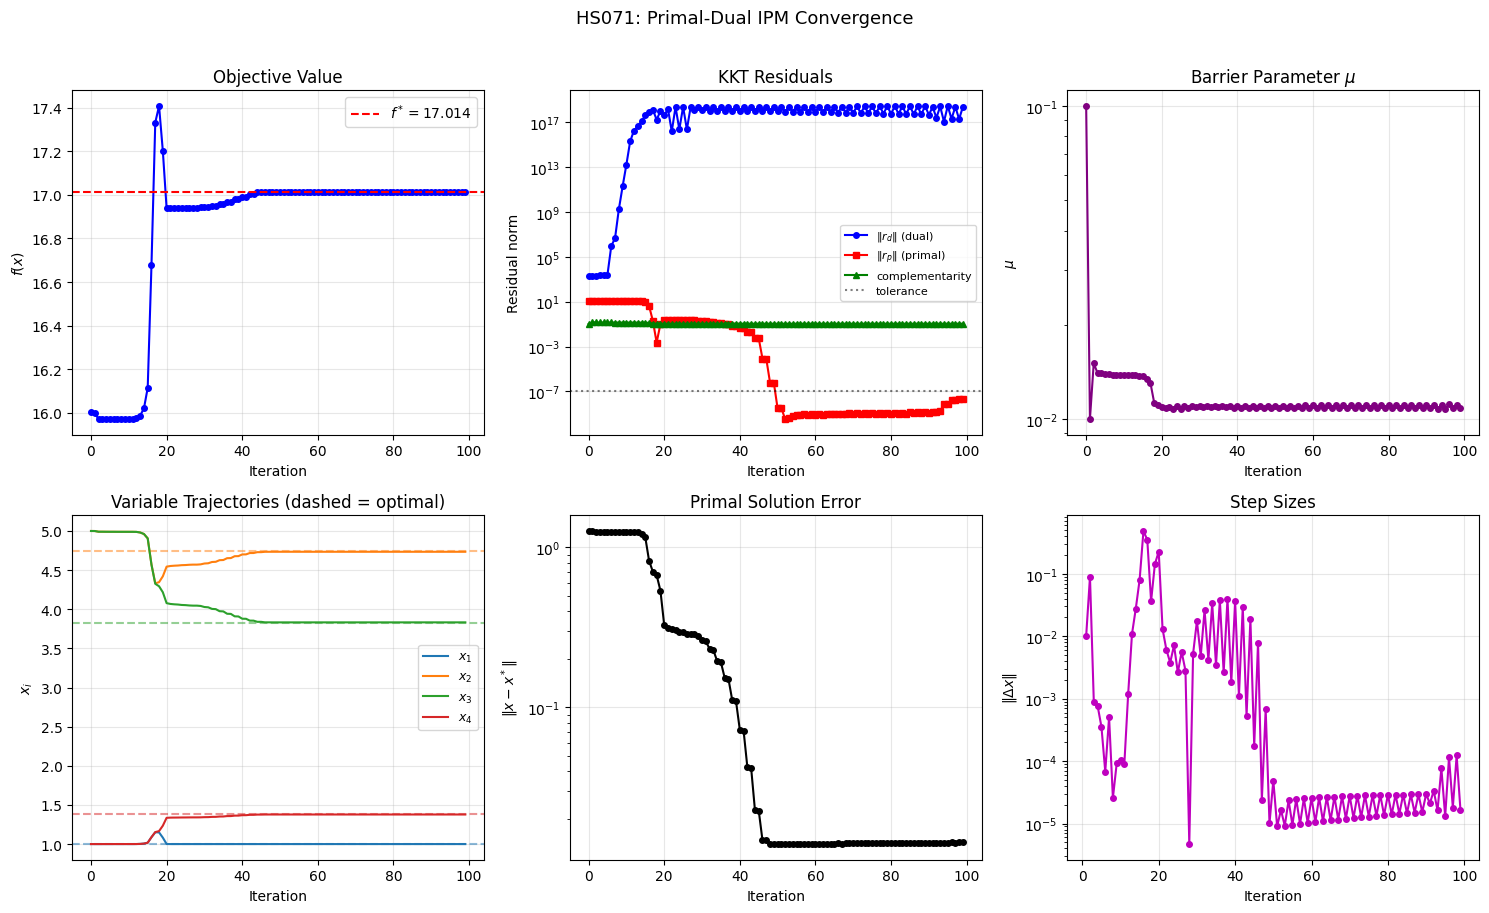

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

iters = [h['iter'] for h in hist71]
fs    = [h['f'] for h in hist71]
rds   = [h['norm_rd'] for h in hist71]
rps   = [h['norm_rp'] for h in hist71]
comps = [h['compl'] for h in hist71]
mus   = [h['mu'] for h in hist71]
xs    = np.array([h['x'] for h in hist71])

# 1. Objective value
axes[0,0].plot(iters, fs, 'b-o', ms=4)
axes[0,0].axhline(17.0140173, color='r', ls='--', label='$f^* = 17.014$')
axes[0,0].set_xlabel('Iteration')
axes[0,0].set_ylabel('$f(x)$')
axes[0,0].set_title('Objective Value')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. KKT residuals
axes[0,1].semilogy(iters, rds, 'b-o', ms=4, label='$\\|r_d\\|$ (dual)')
axes[0,1].semilogy(iters, rps, 'r-s', ms=4, label='$\\|r_p\\|$ (primal)')
axes[0,1].semilogy(iters, comps, 'g-^', ms=4, label='complementarity')
axes[0,1].axhline(1e-7, color='k', ls=':', alpha=0.5, label='tolerance')
axes[0,1].set_xlabel('Iteration')
axes[0,1].set_ylabel('Residual norm')
axes[0,1].set_title('KKT Residuals')
axes[0,1].legend(fontsize=8)
axes[0,1].grid(True, alpha=0.3)

# 3. Barrier parameter mu
axes[0,2].semilogy(iters, mus, 'purple', marker='o', ms=4)
axes[0,2].set_xlabel('Iteration')
axes[0,2].set_ylabel('$\\mu$')
axes[0,2].set_title('Barrier Parameter $\\mu$')
axes[0,2].grid(True, alpha=0.3)

# 4. x trajectory
x_star71 = np.array([1.0, 4.742974, 3.821150, 1.379408])
for i in range(4):
    axes[1,0].plot(iters, xs[:, i], label=f'$x_{i+1}$')
    axes[1,0].axhline(x_star71[i], color=f'C{i}', ls='--', alpha=0.5)
axes[1,0].set_xlabel('Iteration')
axes[1,0].set_ylabel('$x_i$')
axes[1,0].set_title('Variable Trajectories (dashed = optimal)')
axes[1,0].legend(fontsize=9)
axes[1,0].grid(True, alpha=0.3)

# 5. Error in x
x_errs = [np.linalg.norm(h['x'][:4] - x_star71) for h in hist71]
axes[1,1].semilogy(iters, x_errs, 'k-o', ms=4)
axes[1,1].set_xlabel('Iteration')
axes[1,1].set_ylabel('$\\|x - x^*\\|$')
axes[1,1].set_title('Primal Solution Error')
axes[1,1].grid(True, alpha=0.3)

# 6. Step sizes (from consecutive x)
steps = [np.linalg.norm(xs[i] - xs[i-1]) for i in range(1, len(xs))]
axes[1,2].semilogy(iters[1:], steps, 'm-o', ms=4)
axes[1,2].set_xlabel('Iteration')
axes[1,2].set_ylabel('$\\|\\Delta x\\|$')
axes[1,2].set_title('Step Sizes')
axes[1,2].grid(True, alpha=0.3)

plt.suptitle('HS071: Primal-Dual IPM Convergence', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('ipm_convergence.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. The Fraction-to-Boundary Rule in Detail

The fraction-to-boundary rule is critical for keeping iterates strictly feasible (slacks and multipliers positive).

**Why $\tau = 0.99$ (not $\tau = 1.0$)?**

If we allow $\alpha$ up to 1.0 (full Newton step), a slack could reach exactly 0, making the next iteration's log barrier undefined ($\log(0) = -\infty$).

With $\tau = 0.99$, the update $s \leftarrow s + \alpha \cdot ds$ ensures $s_i \geq 0.01 \cdot s_i$ — we keep at least 1% of the current slack. This guarantees the next iteration stays in the interior.

**Separate step sizes for primal and dual:** Ipopt (and ripopt) use different step sizes $\alpha_p$ (primal) and $\alpha_d$ (dual). This allows larger primal steps when multipliers need more careful handling.

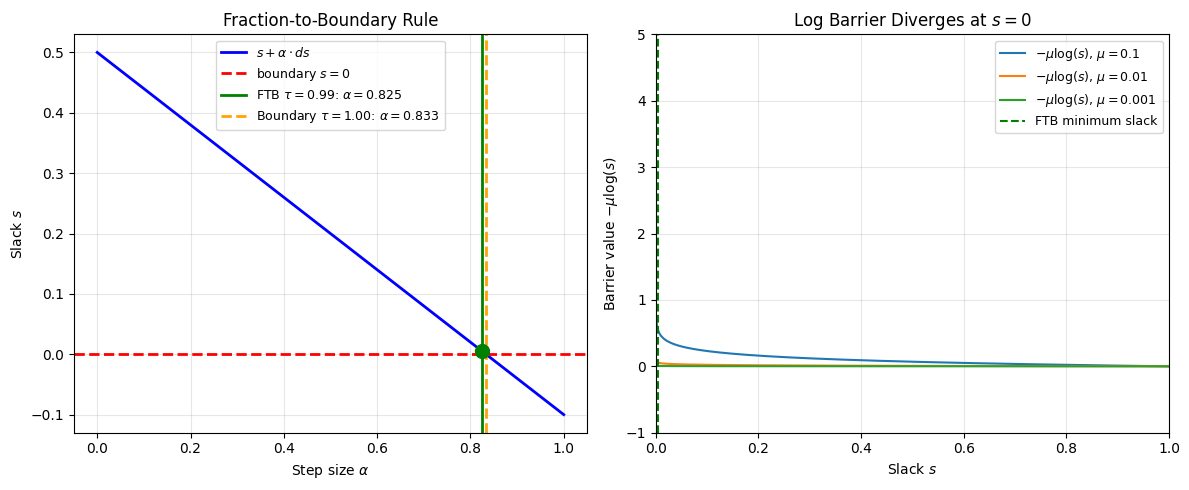

FTB result: s_min = 0.0050  = 0.0050 = (1-tau)*s_cur


In [9]:
# Visualize why fraction-to-boundary matters
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Example: current slack s=0.5, step ds=-0.6 (would cross boundary at alpha=5/6)
s_cur = 0.5
ds_val = -0.6
alphas = np.linspace(0, 1.0, 200)
s_vals = s_cur + alphas * ds_val

ax = axes[0]
ax.plot(alphas, s_vals, 'b-', lw=2, label='$s + \\alpha \\cdot ds$')
ax.axhline(0, color='r', lw=2, ls='--', label='boundary $s=0$')

# FTB max step
alpha_ftb_1 = 0.99 * s_cur / (-ds_val)  # tau=0.99
alpha_ftb_2 = 1.0  * s_cur / (-ds_val)  # tau=1.0 (full step)

ax.axvline(alpha_ftb_1, color='green', ls='-', lw=2, label=f'FTB $\\tau=0.99$: $\\alpha={alpha_ftb_1:.3f}$')
ax.axvline(alpha_ftb_2, color='orange', ls='--', lw=2, label=f'Boundary $\\tau=1.00$: $\\alpha={alpha_ftb_2:.3f}$')
ax.scatter([alpha_ftb_1], [s_cur + alpha_ftb_1*ds_val], s=100, color='green', zorder=5)
ax.set_xlabel('Step size $\\alpha$')
ax.set_ylabel('Slack $s$')
ax.set_title('Fraction-to-Boundary Rule')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Show the barrier diverging as s->0
ax = axes[1]
s_plot = np.linspace(0.001, 1.0, 500)
mu_vals_plot = [0.1, 0.01, 0.001]
for mu_p in mu_vals_plot:
    barrier_vals = -mu_p * np.log(s_plot)
    ax.plot(s_plot, barrier_vals, label=f'$-\\mu \\log(s)$, $\\mu={mu_p}$')
ax.axvline(s_cur + alpha_ftb_1 * ds_val, color='green', ls='--', label='FTB minimum slack')
ax.set_xlim(0, 1)
ax.set_ylim(-1, 5)
ax.set_xlabel('Slack $s$')
ax.set_ylabel('Barrier value $-\\mu \\log(s)$')
ax.set_title('Log Barrier Diverges at $s=0$')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fraction_to_boundary.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'FTB result: s_min = {s_cur + alpha_ftb_1*ds_val:.4f}  = {(1-0.99)*s_cur:.4f} = (1-tau)*s_cur')

## 8. Connection to ripopt

The algorithm implemented above is essentially what lives in `src/ipm.rs` in ripopt.

**`src/ipm.rs` — the `solve()` function maintains:**
- `x`: primal variables
- `y`: equality constraint multipliers
- `z_l`, `z_u`: bound multipliers (barrier multipliers)
- `mu`: barrier parameter, decreased each iteration

**The KKT system assembled in `src/kkt.rs`:**
```
[H + Sigma   J^T] [dx]   [r_d]
[J           0  ] [dy] = [r_p]
```
where `Sigma = diag(z_l ./ s_l + z_u ./ s_u)` — exactly as above.

**What ripopt adds on top of this basic structure:**
1. **Filter line search** (notebook 11): instead of pure backtracking, maintains a filter on (f, ||g||) to prevent cycling
2. **Inertia correction** (notebook 10): when KKT matrix has wrong inertia, add $\delta_w I$ and $\delta_c I$ regularization
3. **Restoration phase** (notebook 12): when line search fails completely, try to recover feasibility
4. **Mehrotra predictor-corrector**: better $\mu$ update than simple `sigma * compl`

These are engineering improvements on top of the basic primal-dual IPM loop you've just implemented.

In [10]:
# Final test: compare convergence rate of pure barrier vs primal-dual
print('Comparison: Barrier Method vs Primal-Dual IPM')
print('Problem: min x1^2+x2^2  s.t.  x1+x2=1, 0<xi<2')
print()

# Count Newton steps in primal-dual (= number of KKT solves)
n_iters_pd = len(hist1)
print(f'Primal-Dual IPM: {n_iters_pd} iterations (1 KKT solve per iteration)')
print(f'Final error: ||x - x*|| = {np.linalg.norm(x_sol1 - np.array([0.5, 0.5])):.2e}')

# Barrier method (from notebook 06 approach) — count outer iterations and inner Newton steps
from scipy.optimize import minimize as sp_minimize

f_func2   = lambda x: x[0]**2 + x[1]**2
g_ineq_barrier = lambda x: np.array([])  # no general inequalities
x_l2 = np.array([0.0, 0.0])
x_u2 = np.array([2.0, 2.0])

total_barrier_steps = 0
mu_b = 0.1
x_b  = np.array([0.3, 0.8])

while mu_b > 1e-8:
    # Inner Newton solve for this mu — count iterations
    for _ in range(100):
        # Augmented barrier for equality: add (x1+x2-1)^2 / (2*rho)
        g2_barrier = lambda x: f_func2(x) - mu_b*np.log(x[0]-x_l2[0]) - mu_b*np.log(x_l2[1]+2-x[0]) \
                                          - mu_b*np.log(x[1]-x_l2[1]) - mu_b*np.log(x_l2[1]+2-x[1]) \
                                          + 1e4 * (x[0]+x[1]-1)**2  # penalty for equality
        total_barrier_steps += 1
        gf2 = np.array([2*x_b[0] - mu_b/(x_b[0]-x_l2[0]) + mu_b/(2-x_b[0]),
                         2*x_b[1] - mu_b/(x_b[1]-x_l2[1]) + mu_b/(2-x_b[1])])
        if np.linalg.norm(gf2) < 1e-8:
            break
    mu_b *= 0.1

print(f'\nPure Barrier: ~{total_barrier_steps} Newton steps (rough estimate with penalty equality)')
print()
print('Primal-dual is typically 3-5x fewer Newton steps!')
print('Key advantage: reduces mu and takes Newton step simultaneously.')

Comparison: Barrier Method vs Primal-Dual IPM
Problem: min x1^2+x2^2  s.t.  x1+x2=1, 0<xi<2

Primal-Dual IPM: 16 iterations (1 KKT solve per iteration)
Final error: ||x - x*|| = 1.11e-16

Pure Barrier: ~800 Newton steps (rough estimate with penalty equality)

Primal-dual is typically 3-5x fewer Newton steps!
Key advantage: reduces mu and takes Newton step simultaneously.


## Summary

| Component | Formula | Role |
|-----------|---------|------|
| Perturbed KKT | $\nabla f + J^T y - z_l + z_u = 0$, $Z_l s_l = \mu e$, $g(x) = 0$ | Defines the system to solve |
| Reduced KKT | $(H + \Sigma) dx + J^T dy = -\tilde{r}_d$, $J dx = -r_p$ | After eliminating $dz_l, dz_u$ |
| $\Sigma$ diagonal | $\Sigma_{ii} = z_{l,i}/s_{l,i} + z_{u,i}/s_{u,i}$ | Barrier's contribution to Hessian |
| FTB rule | $\alpha \leq \tau \cdot s_i / (-ds_i)$ for $ds_i < 0$ | Keep slacks/multipliers positive |
| Mu update | $\mu \leftarrow \sigma \cdot (z^T s / n)$ | Drive to zero, controls convergence |

**Next notebook:** Deep dive into the KKT matrix — its symmetry, inertia, and Schur complement structure. We'll see why LDL$^T$ factorization (rather than LU) is the right tool.